In [52]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch
import random
from sklearn.neighbors import NearestNeighbors
from ex_week_10_utils import (load_mnist_data, plot_data_list, plot_embeddings_2d, 
                               plot_embeddings_comparison, plot_reconstructions,
                               load_model_if_valid, save_model)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Using device: mps


In [53]:
# Load MNIST data using our utility function
train_loader, val_loader, test_loader = load_mnist_data(batch_size=128, validation_split=0.1)

print("Data loaded successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Data loaded successfully!
Train batches: 422
Validation batches: 47
Test batches: 79


In [54]:
# LoRA Implementation
def clf(A1, A2, rank, lambda_B, lambda_C, t, tolerance=1e-4):
    
    B = np.random.randn(A1.shape[0], rank)
    prev_err = np.inf
    
    for i in range(t):
        C1 = np.linalg.inv(B.T @ B + lambda_C * np.eye(rank)) @ B.T @ A1
        C2 = np.linalg.inv(B.T @ B + lambda_C * np.eye(rank)) @ B.T @ A2
        B = (A1 @ C1.T + A2 @ C2.T) @ np.linalg.inv(C1 @ C1.T + C2 @ C2.T + lambda_B * np.eye(rank))
        err1 = np.linalg.norm(A1 - B @ C1, 'fro') ** 2
        err2 = np.linalg.norm(A2 - B @ C2, 'fro') ** 2
        # if (i + 1) % 100 == 0:
        # print(f"Iteration {i + 1}/{t}: Reconstruction error: Model 1: {err1:.4f}, Model 2: {err2:.4f}")
        current_err = err1 + err2
        
        if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:
            # print(f"Convergence reached at iteration {i + 1}.")
            break
        prev_err = current_err
    
    return B, C1, C2

In [55]:
# CNN Autoencoder Implementation
class CNNAutoencoder(nn.Module):
    """
    CNN Autoencoder for MNIST images.
    Compresses 28×28 images into a low-dimensional latent space and reconstructs them.
    """
    def __init__(self, latent_dim=32):
        super(CNNAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder: CNN layers
        self.encoder = nn.Sequential(
            # Input: (batch, 1, 28, 28) #This tells us that there is only 1 color channel in the mnist images
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2, 2),  # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),  # 14x14 -> 7x7
            nn.Flatten(),
            # Add intermediate layer
            nn.Linear(32 * 7 * 7, 128), 
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )
        
        # Decoder: Transpose CNN layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 32 * 7 * 7),
            nn.ReLU(),
            nn.BatchNorm1d(32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] range
        )
    
    def encode(self, x):
        """Extract embeddings from input images."""
        return self.encoder(x)
    
    def decode(self, z):
        """Reconstruct images from embeddings."""
        return self.decoder(z)
    
    def forward(self, x):
        """Forward pass: encode then decode."""
        # TODO: First encode the input, then decode the latent representation
        latent_embedding = self.encode(x)
        x_recon = self.decode(latent_embedding)
        return x_recon


# Training and Evaluation Functions
def train_epoch(model, loader, optimizer, criterion, device):
    """Train autoencoder for one epoch"""
    model.train()
    total_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        
        # TODO: Forward pass - get reconstruction from model
        reconstructions = model(images)
        
        # TODO: Compute loss between reconstructions and original images
        loss = criterion(reconstructions, images)
        
        # TODO: Backward pass - zero gradients, backward, and update weights. You have worked with this before, look through old exercises and assignments if you are in doubt
        # You will write these 3 lines a billion times in your lives as AI engineers, so better get used to them now ;)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    return avg_loss

def evaluate(model, loader, criterion, device):
    """Evaluate autoencoder on a dataset"""
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # TODO: Forward pass - get reconstruction from model
            reconstructions = model(images)
            
            # TODO: Compute loss between reconstructions and original images
            loss = criterion(reconstructions, images)
            
            # Track metrics
            total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    return avg_loss

def train_model(model, train_loader, val_loader, num_epochs, lr, device):
    """Complete training loop for autoencoder"""
    model = model.to(device)
    criterion = nn.MSELoss()  # Reconstruction loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate(model, val_loader, criterion, device)
        
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss: {val_loss:.6f}")
    
    return model

def extract_embeddings(model, loader, device):
    """Extract embeddings and labels from a dataset"""
    model.eval()
    embeddings_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # Get embeddings (encoder only, no classifier)
            emb = model.encode(images)
            
            embeddings_list.append(emb.cpu())
            labels_list.append(labels)
    
    # Concatenate all batches
    embeddings = torch.cat(embeddings_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return embeddings, labels

def compute_mrr(recon1, recon2):
    """
    Mean Reciprocal Rank: for each point i in recon1, rank all points in recon2
    by distance and record the rank of point i (the true match).
    MRR = mean(1 / rank). Perfect alignment → MRR = 1.0.
    """
    n = len(recon1)

    # Pairwise squared distances: (n, n)
    # ||a - b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    r1_sq = np.sum(recon1 ** 2, axis=1, keepdims=True)   # (n, 1)
    r2_sq = np.sum(recon2 ** 2, axis=1, keepdims=True)   # (n, 1)
    dists = r1_sq + r2_sq.T - 2 * (recon1 @ recon2.T)    # (n, n)

    # For each row i, rank of column i (the true match) — argsort gives ascending order
    ranks = (np.argsort(dists, axis=1) == np.arange(n)[:, None]).argmax(axis=1) + 1  # 1-indexed

    mrr = float(np.mean(1.0 / ranks))

    print(f"=== Mean Reciprocal Rank ===")
    print(f"MRR:              {mrr:.4f}  (perfect = 1.0000, random ≈ {1/n:.6f})")
    print(f"Median rank:      {int(np.median(ranks))} / {n}")
    print(f"Rank 1 hits:      {np.sum(ranks == 1)} / {n}  ({np.mean(ranks == 1)*100:.2f}%)")
    print(f"Rank ≤ 10 hits:   {np.sum(ranks <= 10)} / {n}  ({np.mean(ranks <= 10)*100:.2f}%)")

    return mrr, ranks

def knn_alignment_eval(recon1, recon2, labels, k=5):
    """
    Evaluate how well LoRA aligned the two reconstructions using KNN.

    Two metrics:
    1. Label accuracy: for each point in recon1, find k nearest neighbors in recon2
       and check if they share the same label (majority vote prediction).
    2. Index recall@k: for each point i in recon1, check if point i (same sample)
       is among its k nearest neighbors in recon2. Perfect alignment → 100%.
    """
    n = len(labels)

    # Fit KNN on recon2 (the reference space)
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean', n_jobs=-1)
    nn.fit(recon2)

    # Query with recon1
    distances, indices = nn.kneighbors(recon1)  # (n, k)

    # --- Metric 1: Label accuracy via majority vote ---
    neighbor_labels = labels[indices]           # (n, k)
    # Majority vote: pick most common label among k neighbors
    from scipy.stats import mode
    predicted_labels = mode(neighbor_labels, axis=1).mode.flatten()
    label_accuracy = np.mean(predicted_labels == labels)

    # --- Metric 2: Index recall@k ---
    # For point i, is index i among its k nearest neighbors in recon2?
    correct_index_found = np.array([i in indices[i] for i in range(n)])
    index_recall = np.mean(correct_index_found)

    print(f"=== KNN Alignment Evaluation (k={k}) ===")
    print(f"Label accuracy (majority vote):  {label_accuracy:.4f}  ({label_accuracy*100:.2f}%)")
    print(f"  → Random baseline: ~{1/10:.4f} (10 classes)")
    print(f"Index recall@{k}:                 {index_recall:.4f}  ({index_recall*100:.2f}%)")
    print(f"  → Random baseline: ~{k/n:.4f} ({k}/{n})")

    return label_accuracy, index_recall, indices



In [56]:
# Load MNIST data using our utility function
train_loader, val_loader, test_loader = load_mnist_data(batch_size=128, validation_split=0.1)

print("Data loaded successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Data loaded successfully!
Train batches: 422
Validation batches: 47
Test batches: 79


In [57]:
# Hyperparameters
latent_dim = 64  # Latent space dimension
num_epochs = 5   # Number of training epochs
learning_rate = 0.001

# Model save paths (saved in models/ directory)
model1_path = 'models/model1_ae.pth'
model2_path = 'models/model2_ae.pth'

# Train or load Autoencoder 1 with seed 42
print("="*60)
print("Autoencoder 1 (seed=42)")
print("="*60)
set_seed(42)
model1, loaded = load_model_if_valid(model1_path, CNNAutoencoder, device, latent_dim=latent_dim)
if not loaded:
    print("Training Autoencoder 1...")
    model1 = CNNAutoencoder(latent_dim=latent_dim)
    model1 = train_model(model1, train_loader, val_loader, num_epochs, learning_rate, device)
    save_model(model1, model1_path, CNNAutoencoder, latent_dim=latent_dim)

# Train or load Autoencoder 2 with seed 123
print("\n" + "="*60)
print("Autoencoder 2 (seed=123)")
print("="*60)
set_seed(123)
model2, loaded = load_model_if_valid(model2_path, CNNAutoencoder, device, latent_dim=latent_dim)
if not loaded:
    print("Training Autoencoder 2...")
    model2 = CNNAutoencoder(latent_dim=latent_dim)
    model2 = train_model(model2, train_loader, val_loader, num_epochs, learning_rate, device)
    save_model(model2, model2_path, CNNAutoencoder, latent_dim=latent_dim)

print("\n" + "="*60)
print("Both autoencoders ready!")
print("="*60)


Autoencoder 1 (seed=42)
Loaded pre-trained model from models/model1_ae.pth

Autoencoder 2 (seed=123)
Loaded pre-trained model from models/model2_ae.pth

Both autoencoders ready!


Reconstruction Examples from Both Autoencoders
Saved visualization to 'autoencoder_reconstructions.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


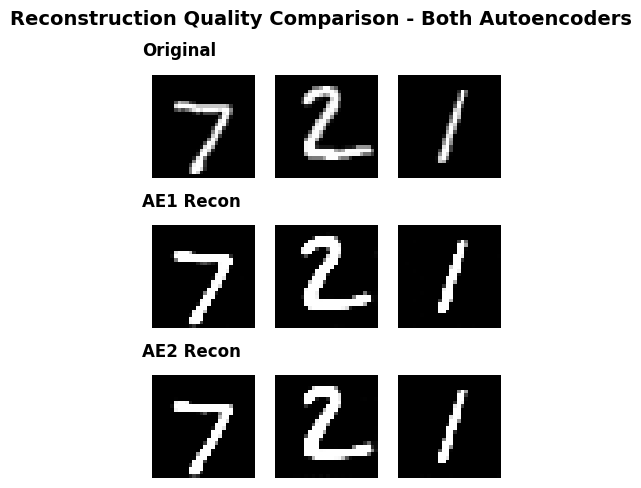

In [58]:
# Show reconstruction examples from both trained autoencoders
print("="*60)
print("Reconstruction Examples from Both Autoencoders")
print("="*60)

# Get a small batch of test images for visualization
test_images_batch, test_labels_batch = next(iter(test_loader))
num_examples = 3
test_images_vis = test_images_batch[:num_examples].to(device)

# Unnormalize images for proper visualization (reverse the normalization)
test_images_unnorm = test_images_vis * 0.3081 + 0.1307
test_images_unnorm = torch.clamp(test_images_unnorm, 0, 1)

# Get reconstructions from both models

#TODO: Put both models into eval mode. This has been done before in previous exercises and assignments
model1.eval()
model2.eval()
with torch.no_grad():
    #TODO: Get reconstructions from each model
    recon1 = model1(test_images_vis)
    recon2 = model2(test_images_vis)

# Plot reconstructions using the utility function
plot_reconstructions(
    images_list=[test_images_unnorm.cpu(), recon1.cpu(), recon2.cpu()],
    row_labels=['Original', 'AE1 Recon', 'AE2 Recon'],
    num_samples=num_examples,
    suptitle='Reconstruction Quality Comparison - Both Autoencoders',
    save_path='autoencoder_reconstructions.png'
)
plt.show()


In [59]:
def extract_embeddings(model, loader, device):
    """Extract embeddings and labels from a dataset"""
    model.eval()
    embeddings_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # Get embeddings (encoder only, no classifier)
            emb = model.encode(images)
            
            embeddings_list.append(emb.cpu())
            labels_list.append(labels)
    
    # Concatenate all batches
    embeddings = torch.cat(embeddings_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return embeddings, labels

# Extract embeddings from both models on the test set
print("Extracting embeddings from Model 1...")
embeddings1, labels1 = extract_embeddings(model1, test_loader, device)

print("Extracting embeddings from Model 2...")
embeddings2, labels2 = extract_embeddings(model2, test_loader, device)

print(f"\nModel 1 embeddings shape: {embeddings1.shape}")
print(f"Model 2 embeddings shape: {embeddings2.shape}")
print(f"Labels shape: {labels1.shape}")

# Verify labels are the same (they should be, since we use the same test set)
assert np.array_equal(labels1, labels2), "Labels should be identical!"
labels = labels1  # Use either one


Extracting embeddings from Model 1...
Extracting embeddings from Model 2...

Model 1 embeddings shape: (10000, 64)
Model 2 embeddings shape: (10000, 64)
Labels shape: (10000,)


In [60]:
# Apply PCA to project 64D embeddings to 2D for visualization

from sklearn.decomposition import PCA

# Model 1: Fit PCA and transform
pca1 = PCA(n_components=2)
embeddings1_2d = pca1.fit_transform(embeddings1)

# Model 2: Fit separate PCA and transform (different embedding space!)
pca2 = PCA(n_components=2)
embeddings2_2d = pca2.fit_transform(embeddings2)


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:309: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 1.0, 0.95, 1))


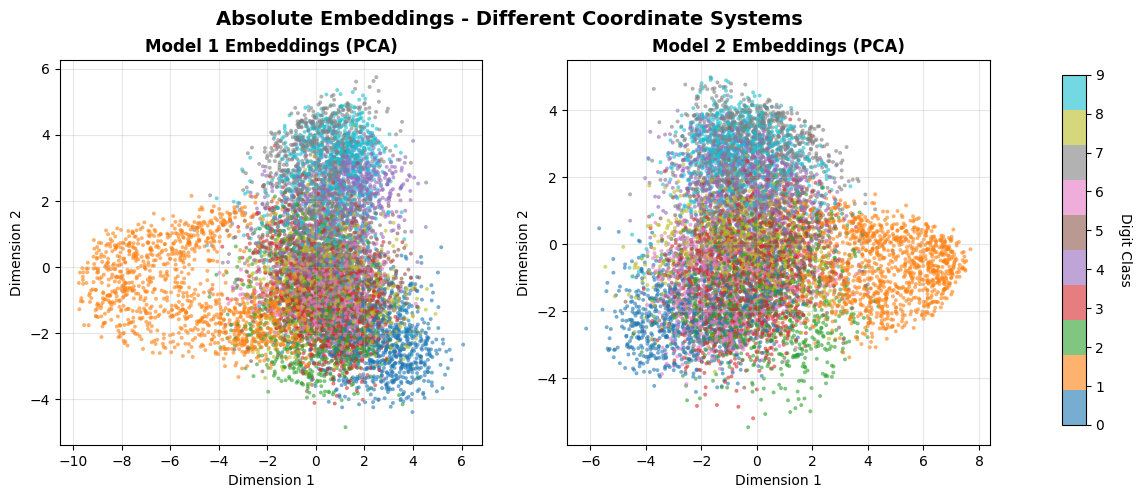

In [61]:
# Plot the 2D projections side by side
fig, axes = plot_embeddings_comparison(
    embeddings1_2d, embeddings2_2d, labels,
    title1='Model 1 Embeddings (PCA)', 
    title2='Model 2 Embeddings (PCA)',
    suptitle='Absolute Embeddings - Different Coordinate Systems'
)
plt.show()

In [62]:
# perform mrr evaluation on the absolute embeddings (before LoRA)
print("Evaluating MRR on absolute embeddings (before LoRA)...")
mrr_before, ranks_before = compute_mrr(embeddings1_2d, embeddings2_2d)


Evaluating MRR on absolute embeddings (before LoRA)...
=== Mean Reciprocal Rank ===
MRR:              0.0021  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      3404 / 10000
Rank 1 hits:      3 / 10000  (0.03%)
Rank ≤ 10 hits:   22 / 10000  (0.22%)


Saved visualization to 'failed_stitching_comparison.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


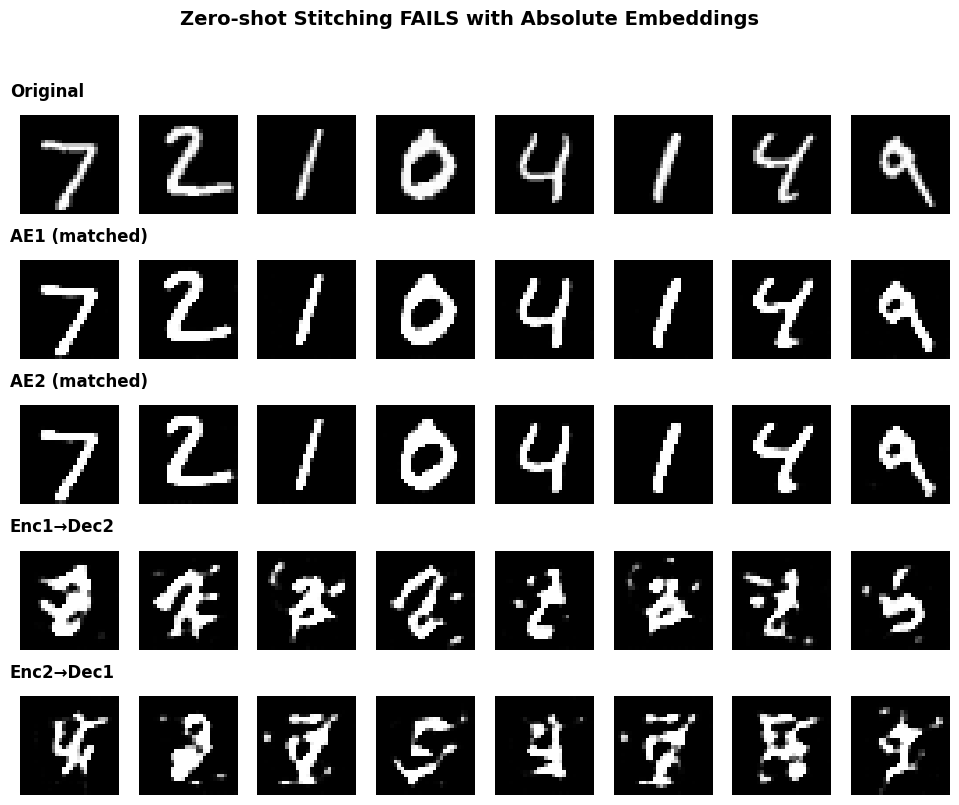

In [63]:
model1.eval()
model2.eval()

# Take 8 test images for visualization (unnormalized for plotting)
vis_images, _ = next(iter(test_loader))
vis_images = vis_images[:8].to(device)
vis_images_unnorm = vis_images * 0.3081 + 0.1307

with torch.no_grad():
    vis_recon1 = model1(vis_images)
    vis_recon2 = model2(vis_images)
    
    # Mismatched reconstructions
    vis_emb1 = model1.encode(vis_images)
    vis_recon1_to_2 = model2.decode(vis_emb1)
    
    vis_emb2 = model2.encode(vis_images)
    vis_recon2_to_1 = model1.decode(vis_emb2)

# Use utility function to plot
plot_reconstructions(
    images_list=[vis_images_unnorm, vis_recon1, vis_recon2, vis_recon1_to_2, vis_recon2_to_1],
    row_labels=['Original', 'AE1 (matched)', 'AE2 (matched)', 'Enc1→Dec2', 'Enc2→Dec1'],
    num_samples=8,
    suptitle='Zero-shot Stitching FAILS with Absolute Embeddings',
    save_path='failed_stitching_comparison.png'
)
plt.show()

In [64]:
# Use LoRA to find a shared latent space between the two models' embeddings
rank = 30  # Low-rank dimension for LoRA
lambda_B = 0.1
lambda_C = 0.1
t = 500  # Number of iterations for LoRA optimization

B, C1, C2 = clf(embeddings1, embeddings2, rank, lambda_B, lambda_C, t)
print(f"LoRA completed with rank={rank}, lambda_B={lambda_B}, lambda_C={lambda_C}, iterations={t}")

recon1 = B @ C1
recon2 = B @ C2

# Print shape of the LoRA reconstructions
print(f"LoRA Recon 1 shape: {recon1.shape}")
print(f"LoRA Recon 2 shape: {recon2.shape}")

/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


LoRA completed with rank=30, lambda_B=0.1, lambda_C=0.1, iterations=500
LoRA Recon 1 shape: (10000, 64)
LoRA Recon 2 shape: (10000, 64)


In [65]:
print(f"LoRA Reconstruction error for Model 1: {np.linalg.norm(embeddings1 - recon1, 'fro') ** 2:.4f}")
print(f"LoRA Reconstruction error for Model 2: {np.linalg.norm(embeddings2 - recon2, 'fro') ** 2:.4f}")

LoRA Reconstruction error for Model 1: 62163.0278
LoRA Reconstruction error for Model 2: 63277.4001


In [66]:
# # Apply PCA to the LoRA reconstructions for visualization
# pca_lora_1_to_2 = PCA(n_components=2)
# recon1_to_2_2d = pca_lora_1_to_2.fit_transform(recon1)
# pca_lora_2_to_1 = PCA(n_components=2)
# recon2_to_1_2d = pca_lora_2_to_1.fit_transform(recon2)
# # Plot the LoRA reconstructions in 2D
# fig, axes = plot_embeddings_comparison(
#     recon1_to_2_2d, recon2_to_1_2d, labels,
#     title1='LoRA Recon 1',
#     title2='LoRA Recon 2',
#     suptitle='LoRA Reconstructions - Aligned Embeddings'
# )
# plt.show()

/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:309: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 1.0, 0.95, 1))


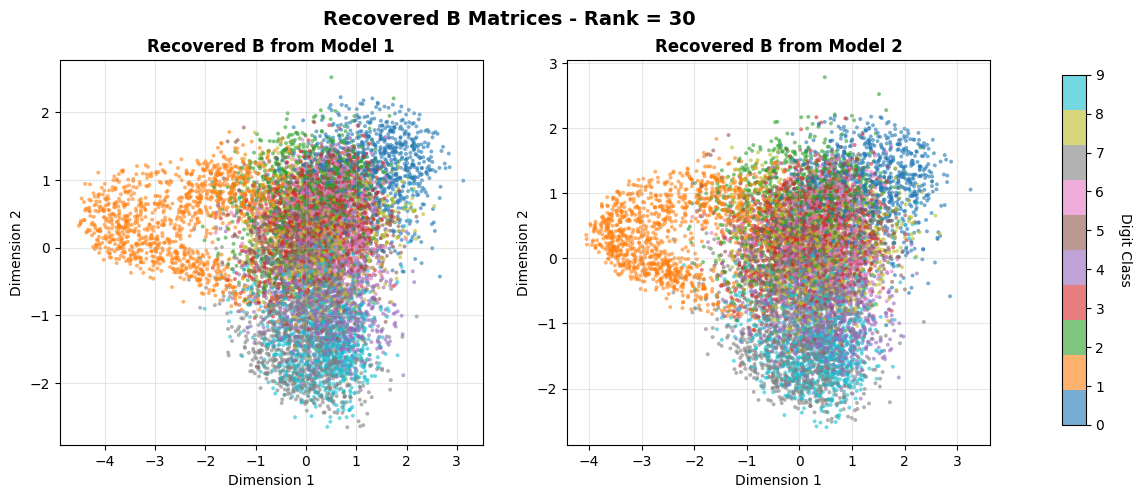

In [67]:
B_recovered1 = embeddings1 @ (C1.T @ np.linalg.inv(C1 @ C1.T + lambda_C * np.eye(rank)))
B_recovered2 = embeddings2 @ (C2.T @ np.linalg.inv(C2 @ C2.T + lambda_C * np.eye(rank)))

recovered_concat = np.concatenate([B_recovered1, B_recovered2], axis=0)
pca_transformed = PCA(n_components=2).fit_transform(recovered_concat)

B_recovered1_2d = pca_transformed[:len(embeddings1)]
B_recovered2_2d = pca_transformed[len(embeddings1):]

# Plot the recovered B matrices in 2D
fig, axes = plot_embeddings_comparison(
    B_recovered1_2d, B_recovered2_2d, labels,
    title1='Recovered B from Model 1',
    title2='Recovered B from Model 2',
    suptitle=f'Recovered B Matrices - Rank = {rank}'
)
plt.show()

In [88]:
# Evaluate MRR on the LoRA reconstructions
print("Evaluating MRR on LoRA reconstructions...")
mrr_after, ranks_after = compute_mrr(B_recovered1, B_recovered2)

Evaluating MRR on LoRA reconstructions...
=== Mean Reciprocal Rank ===
MRR:              0.9947  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      1 / 10000
Rank 1 hits:      9918 / 10000  (99.18%)
Rank ≤ 10 hits:   9994 / 10000  (99.94%)


Shape of concatenated recovered B: (20000, 30)
Shape of B_recovered1_2d: (10000, 2)
Shape of B_recovered2_2d: (10000, 2)
Shape of anchor_dirs1: (30, 64)


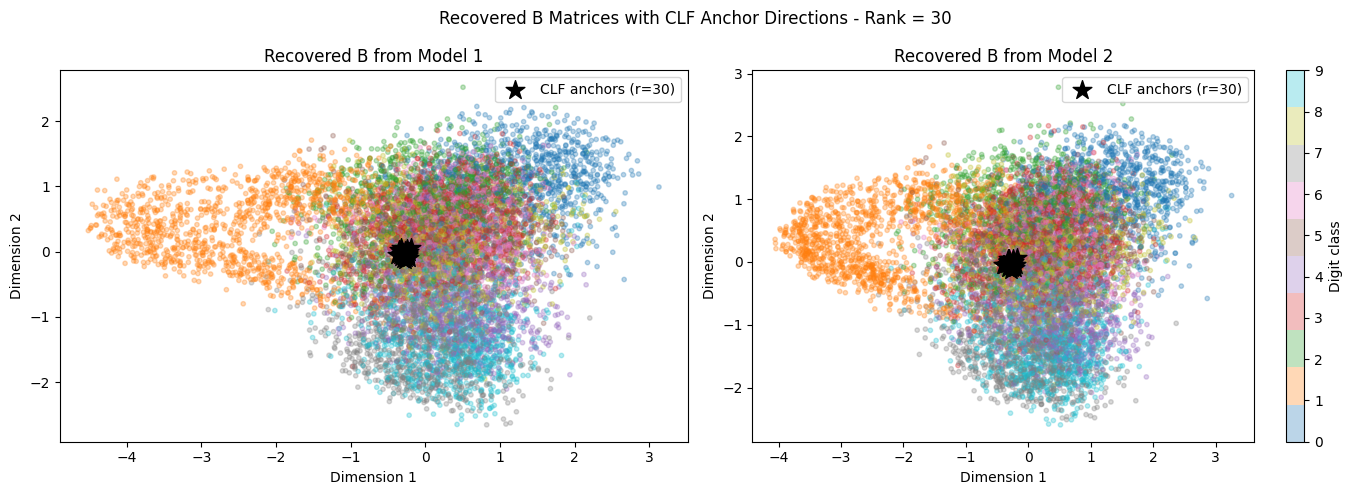

In [68]:
# Compute pseudoinverses
C1_dagger = C1.T @ np.linalg.inv(C1 @ C1.T + lambda_C * np.eye(rank))
C2_dagger = C2.T @ np.linalg.inv(C2 @ C2.T + lambda_C * np.eye(rank))

B_recovered1 = embeddings1 @ C1_dagger
B_recovered2 = embeddings2 @ C2_dagger

# Concatenate and fit PCA
recovered_concat = np.concatenate([B_recovered1, B_recovered2], axis=0)
print(f"Shape of concatenated recovered B: {recovered_concat.shape}")
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(recovered_concat)

B_recovered1_2d = pca_transformed[:len(embeddings1)]
B_recovered2_2d = pca_transformed[len(embeddings1):]
print(f"Shape of B_recovered1_2d: {B_recovered1_2d.shape}")
print(f"Shape of B_recovered2_2d: {B_recovered2_2d.shape}")

# Compute anchor directions in latent space
# Columns of C1_dagger are the anchor directions — shape d x r
# Transpose to get r anchor directions of shape r x d
anchor_dirs1 = C1_dagger.T  # r x d1
anchor_dirs2 = C2_dagger.T  # r x d2
print(f"Shape of anchor_dirs1: {anchor_dirs1.shape}")

# # Project anchor directions into latent space
anchor_latent1 = anchor_dirs1 @ C1_dagger  # r x r
anchor_latent2 = anchor_dirs2 @ C2_dagger  # r x r

# Project through same PCA
anchor1_2d = pca.transform(anchor_latent1)  # r x 2
anchor2_2d = pca.transform(anchor_latent2)  # r x 2

# # Try projecting the original anchor directions
# achor_dirs1_2d = pca.transform(anchor_dirs1)  
# anchor_dirs2_2d = pca.transform(anchor_dirs2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, emb_2d, anchor_2d, title in zip(
    axes,
    [B_recovered1_2d, B_recovered2_2d],
    [anchor1_2d, anchor2_2d],
    ['Recovered B from Model 1', 'Recovered B from Model 2']
):
    # Plot all data points colored by label
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                        c=labels, cmap='tab10', alpha=0.3, s=10)
    
    # Plot anchor directions
    ax.scatter(anchor_2d[:, 0], anchor_2d[:, 1],
              color='black', marker='*', s=200, 
              zorder=5, label=f'CLF anchors (r={rank})')
    
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend()

plt.colorbar(scatter, ax=axes[1], label='Digit class')
plt.suptitle(f'Recovered B Matrices with CLF Anchor Directions - Rank = {rank}')
plt.tight_layout()
plt.show()

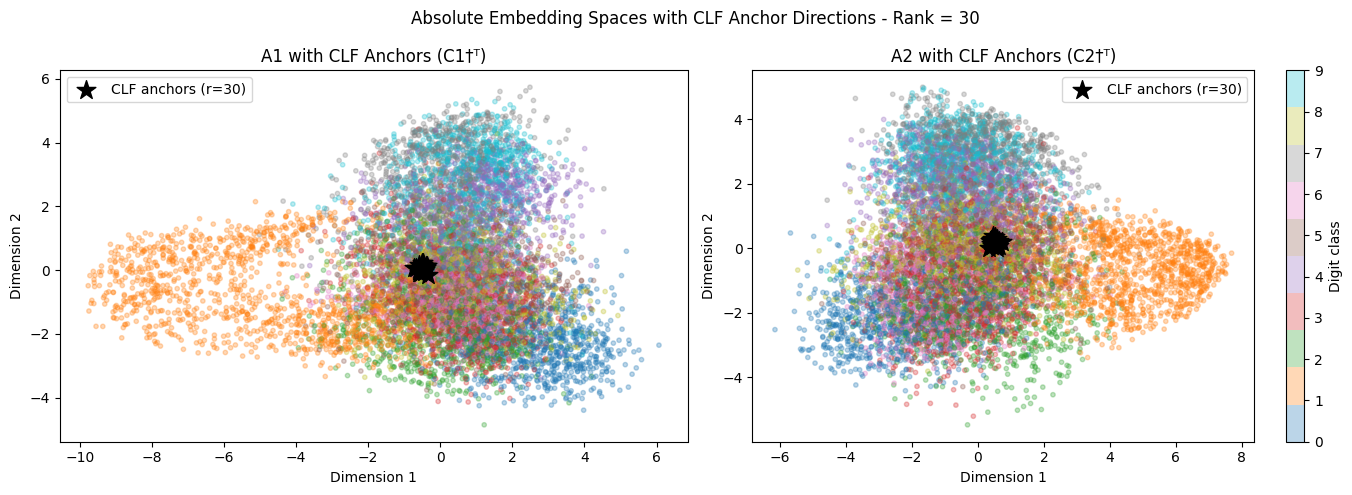

In [69]:
# ── A1 and C1 ─────────────────────────────────────────────────────────────────
pca_A1 = PCA(n_components=2)
A1_2d = pca_A1.fit_transform(embeddings1) # N x 2

# C1_dagger has shape D x R — transpose to get R x D
C1_dagger_T = C1_dagger.T # R x D
C1_anchor_2d = pca_A1.transform(C1_dagger_T) # R x 2

# ── A2 and C2 ─────────────────────────────────────────────────────────────────
pca_A2 = PCA(n_components=2)
A2_2d = pca_A2.fit_transform(embeddings2) # N x 2

C2_dagger_T = C2_dagger.T # R x D
C2_anchor_2d = pca_A2.transform(C2_dagger_T) # R x 2

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, A_2d, anchor_2d, title in zip(
    axes,
    [A1_2d, A2_2d],
    [C1_anchor_2d, C2_anchor_2d],
    ['A1 with CLF Anchors (C1†ᵀ)', 'A2 with CLF Anchors (C2†ᵀ)']
):
    # Plot embeddings colored by label
    scatter = ax.scatter(A_2d[:, 0], A_2d[:, 1],
                        c=labels, cmap='tab10', alpha=0.3, s=10)
    
    # Plot anchor directions
    ax.scatter(anchor_2d[:, 0], anchor_2d[:, 1],
              color='black', marker='*', s=200,
              zorder=5, label=f'CLF anchors (r={rank})')
    
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend()

plt.colorbar(scatter, ax=axes[1], label='Digit class')
plt.suptitle(f'Absolute Embedding Spaces with CLF Anchor Directions - Rank = {rank}')
plt.tight_layout()
plt.show()

/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:309: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 1.0, 0.95, 1))


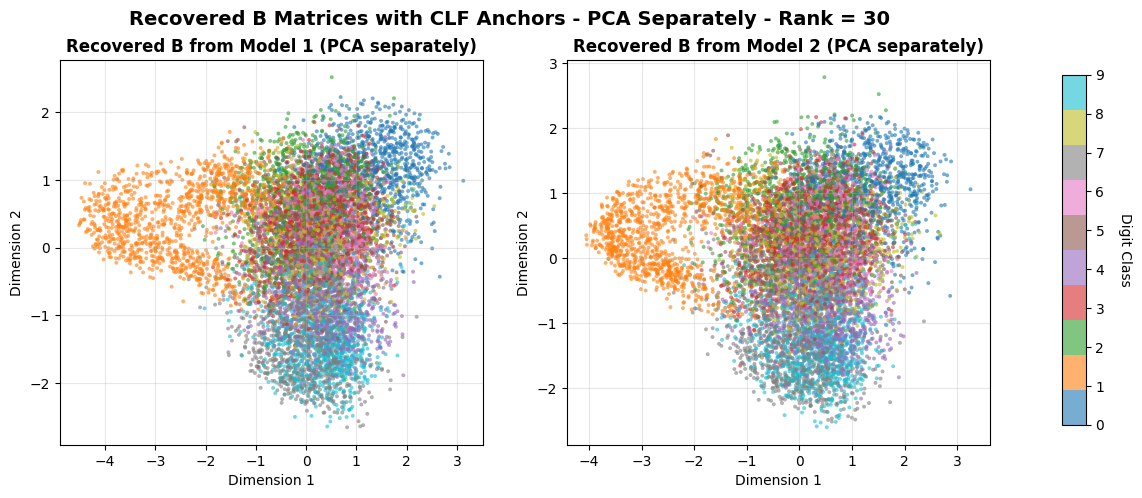

In [70]:
# Fit separate PCA on each — do NOT concatenate
B_recovered1 = embeddings1 @ C1_dagger
B_recovered2 = embeddings2 @ C2_dagger

pca_B1 = PCA(n_components=2)
pca_B2 = PCA(n_components=2)

B_recovered1_2d = pca_B1.fit_transform(B_recovered1)
B_recovered2_2d = pca_B2.fit_transform(B_recovered2)

# Plot separately so scales are visible
fig, axes = plot_embeddings_comparison(
    B_recovered1_2d, B_recovered2_2d, labels,
    title1='Recovered B from Model 1 (PCA separately)',
    title2='Recovered B from Model 2 (PCA separately)',
    suptitle=f'Recovered B Matrices with CLF Anchors - PCA Separately - Rank = {rank}'
)
plt.show()

In [71]:
k = 4

# perform mrr evaluation on the recovered B matrices
print("Evaluating MRR on recovered B matrices...")
mrr_recovered, ranks_recovered = compute_mrr(B_recovered1, B_recovered2)

# perform knn evaluation on the recovered B matrices
print("\nEvaluating KNN alignment on recovered B matrices...")
label_acc_recovered, idx_recall_recovered, neighbor_indices_recovered = knn_alignment_eval(B_recovered1, B_recovered2, labels, k=k)


Evaluating MRR on recovered B matrices...
=== Mean Reciprocal Rank ===
MRR:              0.9951  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      1 / 10000
Rank 1 hits:      9923 / 10000  (99.23%)
Rank ≤ 10 hits:   9994 / 10000  (99.94%)

Evaluating KNN alignment on recovered B matrices...
=== KNN Alignment Evaluation (k=4) ===
Label accuracy (majority vote):  0.9773  (97.73%)
  → Random baseline: ~0.1000 (10 classes)
Index recall@4:                 0.9984  (99.84%)
  → Random baseline: ~0.0004 (4/10000)


/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


=== Mean Reciprocal Rank ===
MRR:              0.1317  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      32 / 10000
Rank 1 hits:      553 / 10000  (5.53%)
Rank ≤ 10 hits:   2828 / 10000  (28.28%)
=== Mean Reciprocal Rank ===
MRR:              0.2917  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      8 / 10000
Rank 1 hits:      1699 / 10000  (16.99%)
Rank ≤ 10 hits:   5479 / 10000  (54.79%)
=== Mean Reciprocal Rank ===
MRR:              0.4958  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      3 / 10000
Rank 1 hits:      3486 / 10000  (34.86%)
Rank ≤ 10 hits:   7866 / 10000  (78.66%)
=== Mean Reciprocal Rank ===
MRR:              0.6713  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      1 / 10000
Rank 1 hits:      5400 / 10000  (54.00%)
Rank ≤ 10 hits:   9167 / 10000  (91.67%)
=== Mean Reciprocal Rank ===
MRR:              0.8012  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      1 / 10000
Rank 1 hits:      7040 / 10000  (70.40%)
Rank ≤ 10 hits:   9658 / 10

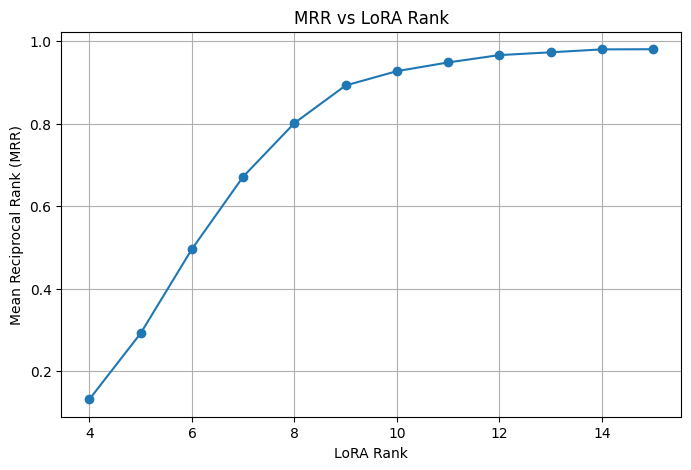

In [84]:
ranks = np.arange(4, 16, 1)  
mrr_values = []

lambda_i = 1e-4

for r in ranks:
    B, C1, C2 = clf(embeddings1, embeddings2, r, lambda_B, lambda_C, t)
    B_recovered1 = embeddings1 @ (C1.T @ np.linalg.inv(C1 @ C1.T + lambda_i * np.eye(r)))
    B_recovered2 = embeddings2 @ (C2.T @ np.linalg.inv(C2 @ C2.T + lambda_i * np.eye(r)))
    mrr, _ = compute_mrr(B_recovered1, B_recovered2)
    mrr_values.append(mrr)

# Plot MRR vs Rank
plt.figure(figsize=(8, 5))
plt.plot(ranks, mrr_values, marker='o')
plt.xlabel('LoRA Rank')
plt.ylabel('Mean Reciprocal Rank (MRR)')
plt.title('MRR vs LoRA Rank')
plt.grid(True)
# plt.savefig('mrr_vs_rank.png')
plt.show()

Rank 4: Mean Reconstruction Error: 5.9152
Rank 8: Mean Reconstruction Error: 5.0976


/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


Rank 12: Mean Reconstruction Error: 4.4670
Rank 16: Mean Reconstruction Error: 3.9322
Rank 20: Mean Reconstruction Error: 3.4530
Rank 24: Mean Reconstruction Error: 3.0106
Rank 28: Mean Reconstruction Error: 2.6046
Rank 32: Mean Reconstruction Error: 2.2138
Rank 36: Mean Reconstruction Error: 1.8550
Rank 40: Mean Reconstruction Error: 1.5059
Rank 44: Mean Reconstruction Error: 1.1914
Rank 48: Mean Reconstruction Error: 0.9181
Rank 52: Mean Reconstruction Error: 0.6762
Rank 56: Mean Reconstruction Error: 0.5712
Rank 60: Mean Reconstruction Error: 0.5105
Rank 64: Mean Reconstruction Error: 0.4634


/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/990823401.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


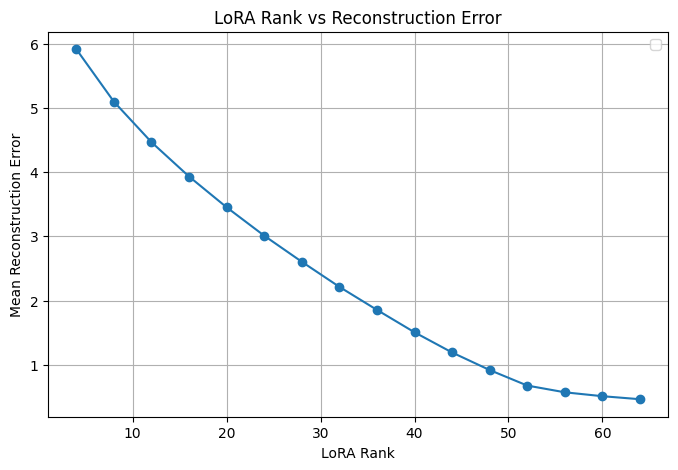

In [73]:
ranks = np.arange(4, 65, 4)  # Ranks from 4 to 64 with step of 4
errs = []
for r in ranks:
    B_r, C1_r, C2_r = clf(embeddings1, embeddings2, r, lambda_B, lambda_C, t)
    recon1_r = B_r @ C1_r
    recon2_r = B_r @ C2_r
    err1 = np.linalg.norm(embeddings1 - recon1_r, axis=-1, ord=2)
    err2 = np.linalg.norm(embeddings2 - recon2_r, axis=-1, ord=2)
    err1 = np.mean(err1)
    err2 = np.mean(err2)
    mean_err = (err1 + err2) / 2
    errs.append(mean_err)
    print(f"Rank {r}: Mean Reconstruction Error: {mean_err:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(ranks, errs, marker='o')
plt.xlabel('LoRA Rank')
plt.ylabel('Mean Reconstruction Error')
plt.title('LoRA Rank vs Reconstruction Error')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
ranks = np.arange(4, 65, 4)  # Ranks from 4 to 64 with step of 4
errs = []
for r in ranks:
    B_r, C1_r, C2_r = clf(embeddings1, embeddings2, r, lambda_B, lambda_C, t)
    recon1_r = B_r @ C1_r
    recon2_r = B_r @ C2_r
    cosine_sim = np.sum(recon1_r * recon2_r, axis=-1) / (np.linalg.norm(recon1_r, axis=-1) * np.linalg.norm(recon2_r, axis=-1) + 1e-8)
    mean_cosine_sim = np.mean(cosine_sim)
    errs.append(mean_cosine_sim)
    print(f"Rank {r}: Mean Cosine Similarity: {mean_cosine_sim:.4f}")

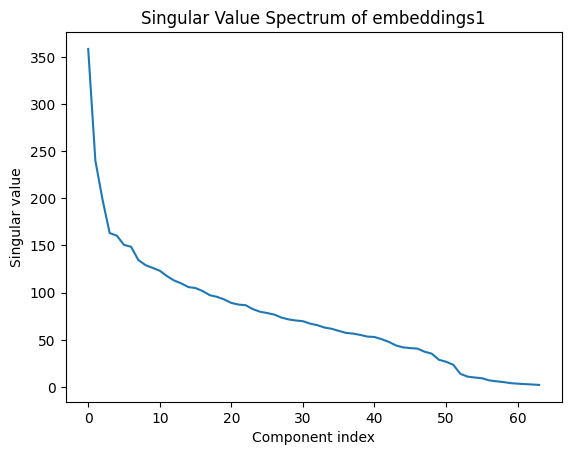

Rank needed for 90% variance: 30
Rank_90 = 30
[0.21111135 0.30585667 0.37077302 0.4145436  0.45684385 0.49413893
 0.5304375  0.5602366  0.5876771  0.6138809  0.6388407  0.6615606
 0.68250257 0.70233285 0.72077674 0.73885113 0.75584215 0.7713927
 0.7864001  0.8005541  0.8136091  0.8261533  0.8384992  0.84969723
 0.8601678  0.8702737  0.8799518  0.8888462  0.89728403 0.9054535
 0.91344845 0.92086315 0.92792225 0.93445677 0.9407136  0.9465356
 0.9519437  0.9572086  0.96221584 0.9669093  0.9715229  0.97574127
 0.97950554 0.9826893  0.9855854  0.98838025 0.9911023  0.99339956
 0.9954515  0.99681836]
358.3899


In [74]:
U, S, Vt = np.linalg.svd(embeddings1, full_matrices=False)

# Scree plot
plt.plot(S)
plt.xlabel('Component index')
plt.ylabel('Singular value')
plt.title('Singular Value Spectrum of embeddings1')
plt.show()

# Explained variance
explained = np.cumsum(S**2) / np.sum(S**2)
rank_90 = np.searchsorted(explained, 0.90) + 1
print(f"Rank needed for 90% variance: {rank_90}")
print(f"Rank_90 = {rank_90}")
print(explained[:50])
print(S[0])

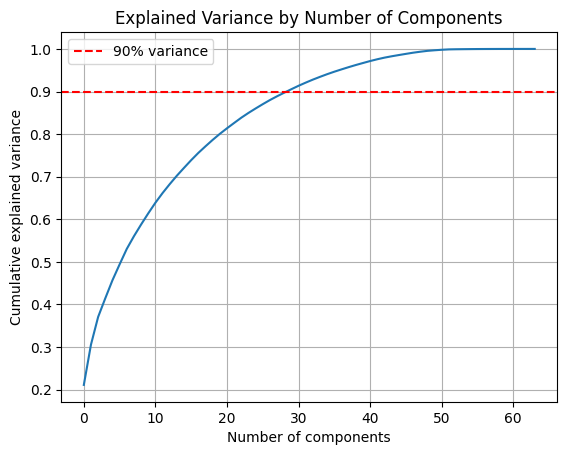

In [75]:
# plot explained variance
plt.plot(explained)
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained Variance by Number of Components')
plt.legend()
plt.grid(True)
plt.show()

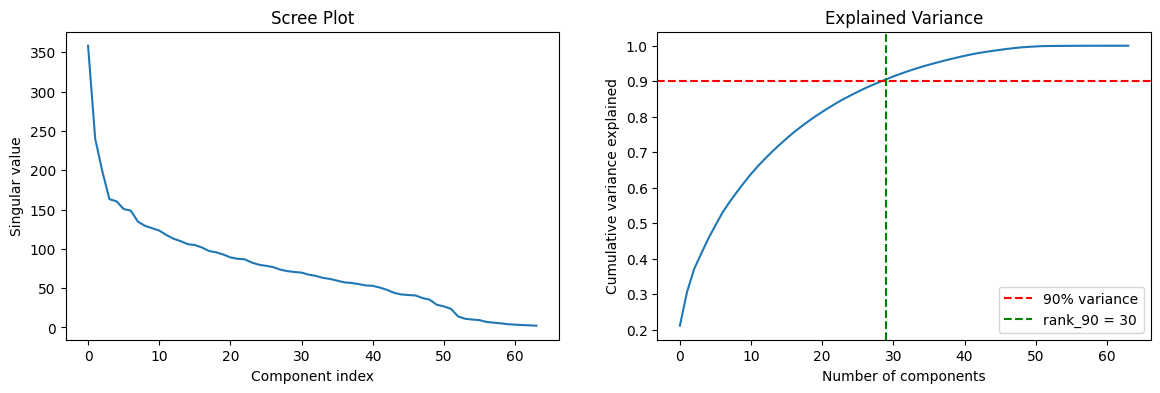

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(S)
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Component index')
axes[0].set_ylabel('Singular value')

axes[1].plot(np.cumsum(S**2) / np.sum(S**2))
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% variance')
axes[1].axvline(x=rank_90-1, color='g', linestyle='--', label=f'rank_90 = {rank_90}')
axes[1].set_title('Explained Variance')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].legend()

In [76]:
# TODO:
# 1. Plot embeddings comparison again with the anchor points highlighted (the columns of the pseudo-inverse matrices C1 and C2)
# 2. Assess the rank using the following:
# @torch.no_grad()
# def rankMe(Z, eps: float = 1.0e-6):
#     """
#     Implementation of RankMe:
#     Assessing the Downstream Performance of Pretrained Self-Supervised Representations by Their Rank
#     Taken an NxK embeddingmatrix Z as input and returns a smooth rank measure.
#     """
#     z_stds = Z.std(dim=0)
#     p_k = z_stds / (torch.norm(z_stds, p=1) + eps)
#     r_k = p_k * torch.log(p_k)
#     return torch.exp(-r_k.sum())
# 3. Train a model to take in th relative embeddings from the two models (the B matrix) so that we can perform zero-shot stitching by feeding the B matrix into both decoders. This is a bit more involved, but it would be a very cool demonstration of the power of LoRA for model alignment!
# 4. Implement text-image alignment using CLIP

In [77]:
# Assessing the rank of the original embeddings using RankMe
import torch
def rankMe(Z, eps: float = 1.0e-6):
    """
    Implementation of RankMe:
    Assessing the Downstream Performance of Pretrained Self-Supervised Representations by Their Rank
    Taken an NxK embeddingmatrix Z as input and returns a smooth rank measure.
    """
    z_stds = Z.std(dim=0)
    p_k = z_stds / (torch.norm(z_stds, p=1) + eps)
    r_k = p_k * torch.log(p_k)
    return torch.exp(-r_k.sum())
embeddings1_tensor = torch.from_numpy(embeddings1)
rank_estimate = rankMe(embeddings1_tensor)
print(f"Estimated rank of embeddings1 using RankMe: {rank_estimate:.2f}")

Estimated rank of embeddings1 using RankMe: 63.96


In [78]:
def rankMe(Z, eps=1e-6):
    z_stds = Z.std(dim=0)
    p_k = z_stds / (torch.norm(z_stds, p=1) + eps)
    r_k = p_k * torch.log(p_k + eps)  # add eps inside log too for safety
    return torch.exp(-r_k.sum()).item()

# Convert your numpy embeddings to torch
Z1 = torch.tensor(embeddings1, dtype=torch.float32)
Z2 = torch.tensor(embeddings2, dtype=torch.float32)

rank1 = rankMe(Z1)
rank2 = rankMe(Z2)
print(f"Estimated rank of embeddings1: {rank1:.2f}")
print(f"Estimated rank of embeddings2: {rank2:.2f}")

Estimated rank of embeddings1: 63.96
Estimated rank of embeddings2: 63.96


In [79]:
class RelativeDecoder(nn.Module):
    """
    Decoder that takes relative representations as input and reconstructs images.
    """
    def __init__(self, input_dim):
        super(RelativeDecoder, self).__init__()
        
        # Decode directly from relative representations to images
        self.decoder = nn.Sequential(
            # Map from relrep dimension to intermediate size
            # TODO: This is just a new decoder. You can just straight up copy the decoder architecture in here and change the input var
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 32 * 7 * 7), # Hint: We are basically constructing the inverse of the encoder
            nn.ReLU(),
            nn.BatchNorm1d(32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            # Upsample: 7x7 -> 14x14
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            # Upsample: 14x14 -> 28x28
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] range
        )
    
    def forward(self, relrep):
        """Forward pass: decode from relrep to image."""
        return self.decoder(relrep)
    
rank = 30
B, C1, C2 = clf(embeddings1, embeddings2, rank, lambda_B, lambda_C, t)

C1_dagger = C1.T @ np.linalg.inv(C1 @ C1.T + lambda_C * np.eye(rank))
C2_dagger = C2.T @ np.linalg.inv(C2 @ C2.T + lambda_C * np.eye(rank))

B_recovered1 = embeddings1 @ C1_dagger
B_recovered2 = embeddings2 @ C2_dagger

print("Preparing datasets for RelativeDecoder training...")

B_recovered1_tensor = torch.FloatTensor(B_recovered1)
B_recovered2_tensor = torch.FloatTensor(B_recovered2)

# Get images from test set (need to unnormalize and reshape properly)
images_list = []
for images, labels_batch in test_loader:
    images_list.append(images)
images_all = torch.cat(images_list, dim=0)

# Unnormalize images (reverse the normalization: x * std + mean)
images_all = images_all * 0.3081 + 0.1307
images_all = torch.clamp(images_all, 0, 1)  # Ensure in [0, 1] range

# Create datasets: (B_recovered, images)
B_recovered1_dataset = TensorDataset(B_recovered1_tensor, images_all)
# B_recovered2_dataset = TensorDataset(B_recovered2_tensor, images_all)

B_recovered1_loader = DataLoader(B_recovered1_dataset, batch_size=128, shuffle=True)
# B_recovered2_loader = DataLoader(B_recovered2_dataset, batch_size=128, shuffle=False)

# Train the RelativeDecoder on Autoencoder 1's relative representations
print("="*60)
print("RelativeDecoder on Autoencoder 1's relreps")
print("="*60)

rel_decoder = RelativeDecoder(input_dim=rank) 
rel_decoder = rel_decoder.to(device)

num_epochs_rel = 25
optimizer = torch.optim.Adam(rel_decoder.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()  # Reconstruction loss

for epoch in range(num_epochs_rel):
    rel_decoder.train()
    total_loss = 0.0
    
    for relreps, images_batch in B_recovered1_loader:
        relreps = relreps.to(device)
        images_batch = images_batch.to(device)
        
        # Forward pass: decode from relative representation to image
        reconstructions = rel_decoder(relreps)
        loss = criterion(reconstructions, images_batch)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(B_recovered1_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs_rel - 1:
        print(f"Epoch {epoch+1}/{num_epochs_rel}, Loss: {avg_loss:.6f}")

print("RelativeDecoder training complete!")


/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


Preparing datasets for RelativeDecoder training...
RelativeDecoder on Autoencoder 1's relreps
Epoch 1/25, Loss: 0.190121
Epoch 5/25, Loss: 0.016281
Epoch 10/25, Loss: 0.010070
Epoch 15/25, Loss: 0.008325
Epoch 20/25, Loss: 0.007663
Epoch 25/25, Loss: 0.007398
RelativeDecoder training complete!


Saved visualization to 'successful_stitching_comparison rank=30.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


(<Figure size 1500x900 with 50 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

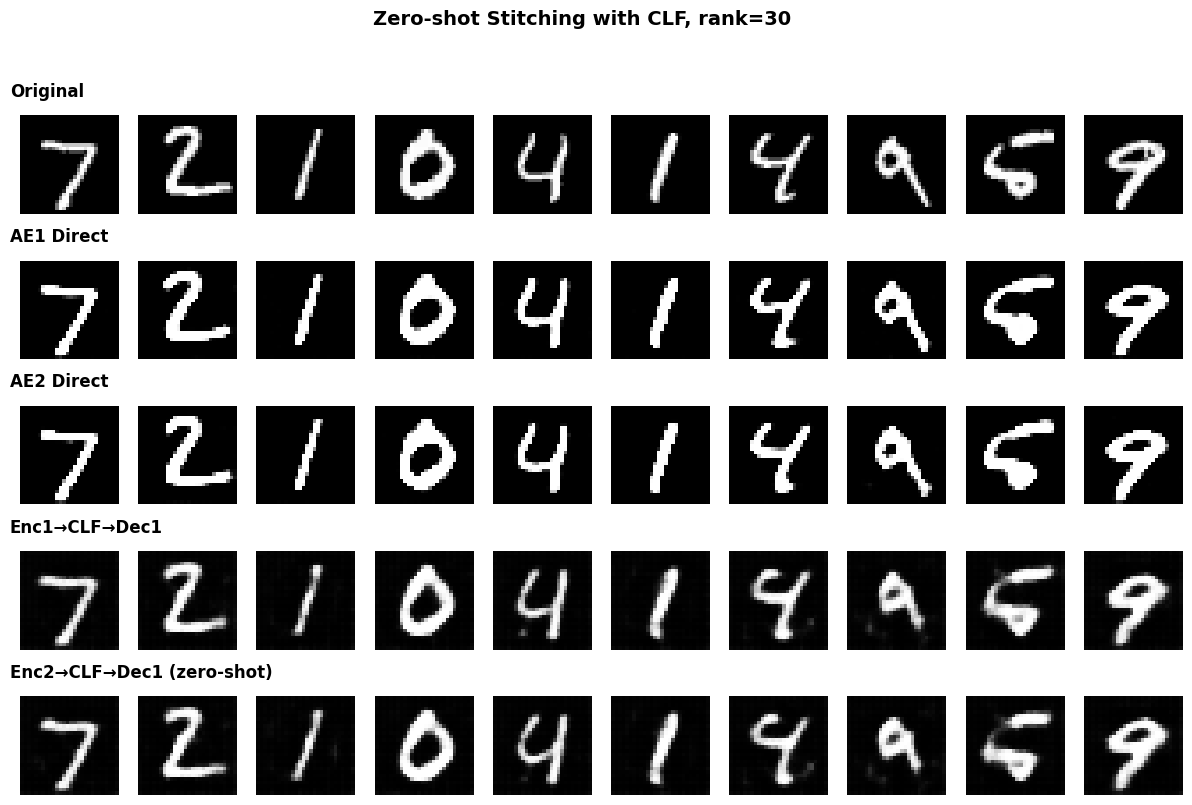

In [80]:
## Getting the reconstructions and plotting ##

# Visualize reconstructions
num_samples = 10

# Get a batch of test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:num_samples].to(device)
test_labels = test_labels[:num_samples]

# Unnormalize for visualization
test_images_unnorm = test_images * 0.3081 + 0.1307

# Get direct reconstructions from both autoencoders
# Don't mind the .cpu() and FLoatTensor stuff. It's just to make sure that it works with numpy and plt
with torch.no_grad():
    recon1_direct = model1(test_images).cpu()
    recon2_direct = model2(test_images).cpu()

    # Get embeddings from both models
    emb_model1 = model1.encode(test_images).cpu().numpy()
    emb_model2 = model2.encode(test_images).cpu().numpy()
    
    # Compute relative representations using the learned LoRA matrices
    latent_model1 = emb_model1 @ C1_dagger  # shape: (num_samples, rank)
    latent_model2 = emb_model2 @ C2_dagger  # shape: (num_samples, rank)
    latent_model1_tensor = torch.FloatTensor(latent_model1).to(device)
    latent_model2_tensor = torch.FloatTensor(latent_model2).to(device)


    # Zero-shot reconstruction
    recon1_from_latent_rep = rel_decoder(latent_model1_tensor).cpu()
    recon2_from_latent_rep = rel_decoder(latent_model2_tensor).cpu()

# Use utility function to plot
plot_reconstructions(
    images_list=[test_images_unnorm.cpu(), recon1_direct, recon2_direct, recon1_from_latent_rep, recon2_from_latent_rep],
    row_labels=['Original', 'AE1 Direct', 'AE2 Direct', 'Enc1→CLF→Dec1', 'Enc2→CLF→Dec1 (zero-shot)'],
    num_samples=num_samples,
    suptitle=f'Zero-shot Stitching with CLF, rank={rank}',
    save_path=f'successful_stitching_comparison rank={rank}.png'
)

/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


Zero-shot reconstruction error: 74057.5332
Direct reconstruction error: 59739.6981
=== Mean Reciprocal Rank ===
MRR:              0.9908  (perfect = 1.0000, random ≈ 0.000100)
Median rank:      1 / 10000
Rank 1 hits:      9843 / 10000  (98.43%)
Rank ≤ 10 hits:   9997 / 10000  (99.97%)
Saved visualization to 'zero_shot_reconstruction_rank_30.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


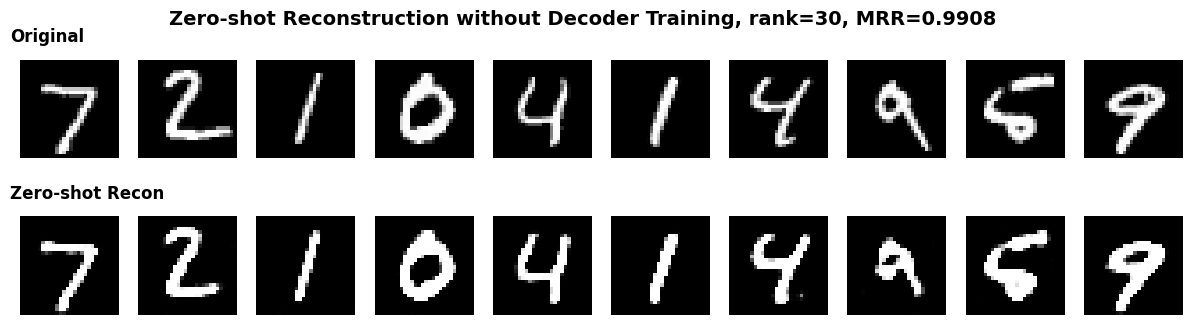

Cosine similarity between zero-shot reconstructions and original embeddings:
Mean: 0.9373
Std: 0.0308
Min: 0.7653
Max: 0.9940


In [87]:
rank = 30
B, C1, C2 = clf(embeddings1, embeddings2, rank, lambda_B, lambda_C, t)
C1_dagger = C1.T @ np.linalg.inv(C1 @ C1.T + lambda_C * np.eye(rank))
C2_dagger = C2.T @ np.linalg.inv(C2 @ C2.T + lambda_C * np.eye(rank))
B_recovered1 = embeddings1 @ C1_dagger
B_recovered2 = embeddings2 @ C2_dagger

# performing zero-shot stitching without training a new decoder
A_2 = B_recovered1 @ C2


recon_error = np.linalg.norm(embeddings2 - A_2, 'fro') ** 2
print(f"Zero-shot reconstruction error: {recon_error:.4f}")

# Compare against direct reconstruction
A_2_direct = B_recovered2 @ C2
direct_error = np.linalg.norm(embeddings2 - A_2_direct, 'fro') ** 2
print(f"Direct reconstruction error: {direct_error:.4f}")

mrr, ranks = compute_mrr(A_2, embeddings2)

with torch.no_grad():
    A_2_tensor = torch.FloatTensor(A_2).to(device)
    recon_images = model2.decode(A_2_tensor).cpu()

# Plot the reconstructions
plot_reconstructions(
    images_list=[test_images_unnorm.cpu(), recon_images],
    row_labels=['Original', 'Zero-shot Recon'],
    num_samples=num_samples,
    suptitle=f'Zero-shot Reconstruction without Decoder Training, rank={rank}, MRR={mrr:.4f}',
    save_path=f'zero_shot_reconstruction_rank_{rank}.png'
)
plt.show()

# cosine similarity between the zero-shot reconstructions and the original embeddings
cosine_sim = np.sum(A_2 * embeddings2, axis=-1) / (np.linalg.norm(A_2, axis=-1) * np.linalg.norm(embeddings2, axis=-1) + 1e-8)
mean_cosine_sim = np.mean(cosine_sim)
std_cosine_sim = np.std(cosine_sim)
min_cosine_sim = np.min(cosine_sim)
max_cosine_sim = np.max(cosine_sim)
print(f"Cosine similarity between zero-shot reconstructions and original embeddings:")
print(f"Mean: {mean_cosine_sim:.4f}")
print(f"Std: {std_cosine_sim:.4f}")
print(f"Min: {min_cosine_sim:.4f}")
print(f"Max: {max_cosine_sim:.4f}")


/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


Rank 4: Mean cosine similarity: 0.6779
Rank 5: Mean cosine similarity: 0.7079
Rank 6: Mean cosine similarity: 0.7342
Rank 7: Mean cosine similarity: 0.7594
Rank 8: Mean cosine similarity: 0.7724
Rank 9: Mean cosine similarity: 0.7859
Rank 10: Mean cosine similarity: 0.8028
Rank 11: Mean cosine similarity: 0.8142
Rank 12: Mean cosine similarity: 0.8262
Rank 13: Mean cosine similarity: 0.8359
Rank 14: Mean cosine similarity: 0.8461
Rank 15: Mean cosine similarity: 0.8562
Rank 16: Mean cosine similarity: 0.8644
Rank 17: Mean cosine similarity: 0.8725
Rank 18: Mean cosine similarity: 0.8785
Rank 19: Mean cosine similarity: 0.8849
Rank 20: Mean cosine similarity: 0.8913
Rank 21: Mean cosine similarity: 0.8966
Rank 22: Mean cosine similarity: 0.9017
Rank 23: Mean cosine similarity: 0.9069
Rank 24: Mean cosine similarity: 0.9106
Rank 25: Mean cosine similarity: 0.9146
Rank 26: Mean cosine similarity: 0.9180
Rank 27: Mean cosine similarity: 0.9218
Rank 28: Mean cosine similarity: 0.9251
Rank 2

/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/2508398587.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


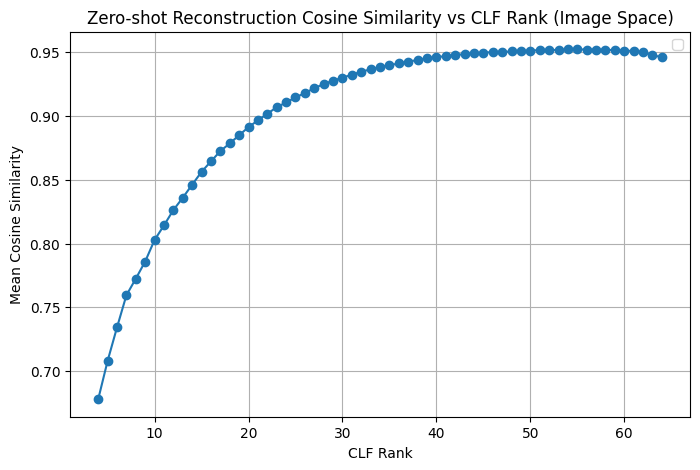

Best mean cosine similarity: 0.9524 at rank 54


In [90]:
ranks = np.arange(4, 65, 1)
zero_shot_cosine = []

for r in ranks:
    B, C1, C2 = clf(embeddings1, embeddings2, r, lambda_B, lambda_C, t)
    C1_dagger = C1.T @ np.linalg.inv(C1 @ C1.T + lambda_C * np.eye(r))
    B_recovered1 = embeddings1 @ C1_dagger
    A_2 = B_recovered1 @ C2

    # Decode to image space
    with torch.no_grad():
        A_2_tensor = torch.FloatTensor(A_2).to(device)
        recon_images = model2.decode(A_2_tensor).cpu().numpy()

    # Flatten images to vectors
    original_flat = images_all.numpy().reshape(len(images_all), -1)
    recon_flat    = recon_images.reshape(len(recon_images), -1)

    # Pairwise cosine similarity per image
    orig_norm  = original_flat / (np.linalg.norm(original_flat, axis=1, keepdims=True) + 1e-8)
    recon_norm = recon_flat    / (np.linalg.norm(recon_flat,    axis=1, keepdims=True) + 1e-8)
    cos_sims   = np.sum(orig_norm * recon_norm, axis=1)

    mean_cos = cos_sims.mean()
    zero_shot_cosine.append(mean_cos)
    print(f"Rank {r}: Mean cosine similarity: {mean_cos:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ranks, zero_shot_cosine, marker='o')
plt.xlabel('CLF Rank')
plt.ylabel('Mean Cosine Similarity')
plt.title('Zero-shot Reconstruction Cosine Similarity vs CLF Rank (Image Space)')
plt.legend()
plt.grid(True)
plt.show()

best_rank  = ranks[np.argmax(zero_shot_cosine)]
best_cos   = max(zero_shot_cosine)
print(f"Best mean cosine similarity: {best_cos:.4f} at rank {best_rank}")

/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_62548/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


CLF zero-shot image MSE threshold: 0.015289
Epoch 1: Image MSE = 0.223722
Epoch 2: Image MSE = 0.073586
Epoch 3: Image MSE = 0.029033
Epoch 4: Image MSE = 0.016614
Epoch 5: Image MSE = 0.012129
Matched CLF zero-shot threshold at epoch 5!


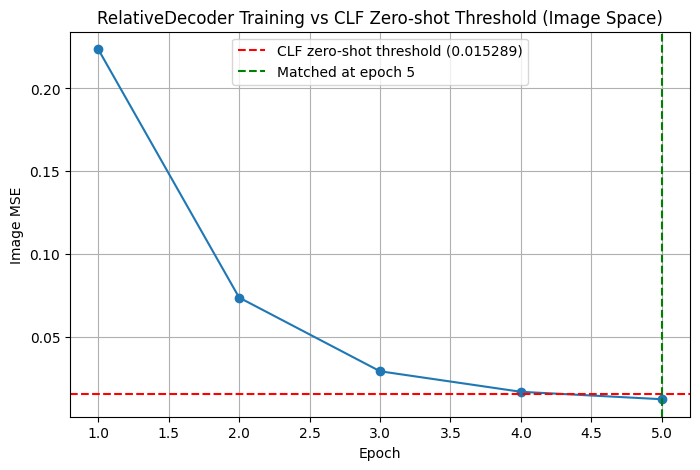

In [83]:
# Train RelativeDecoder and track when it reaches the CLF zero-shot error threshold
rank = 54

B, C1, C2 = clf(embeddings1, embeddings2, rank, lambda_B, lambda_C, t)
C1_dagger = C1.T @ np.linalg.inv(C1 @ C1.T + lambda_C * np.eye(rank))
B_recovered1 = embeddings1 @ C1_dagger

# Compute CLF zero-shot threshold in image space
A_2_zeroshot = B_recovered1 @ C2
with torch.no_grad():
    A_2_tensor = torch.FloatTensor(A_2_zeroshot).to(device)
    recon_zeroshot = model2.decode(A_2_tensor).cpu()
clf_threshold = nn.MSELoss()(recon_zeroshot, images_all).item()
print(f"CLF zero-shot image MSE threshold: {clf_threshold:.6f}")

# Setup decoder training
B_recovered1_tensor = torch.FloatTensor(B_recovered1)
B_recovered1_dataset = TensorDataset(B_recovered1_tensor, images_all)
B_recovered1_loader = DataLoader(B_recovered1_dataset, batch_size=128, shuffle=True)

rel_decoder = RelativeDecoder(input_dim=rank).to(device)
optimizer = torch.optim.Adam(rel_decoder.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

epoch_losses = []
epochs_to_match = None
max_epochs = 200

for epoch in range(max_epochs):
    rel_decoder.train()
    total_loss = 0.0
    
    for relreps, images_batch in B_recovered1_loader:
        relreps = relreps.to(device)
        images_batch = images_batch.to(device)
        reconstructions = rel_decoder(relreps)
        loss = criterion(reconstructions, images_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(B_recovered1_loader)
    epoch_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}: Image MSE = {avg_loss:.6f}")
    
    if avg_loss <= clf_threshold and epochs_to_match is None:
        epochs_to_match = epoch + 1
        print(f"Matched CLF zero-shot threshold at epoch {epochs_to_match}!")
        break

if epochs_to_match is None:
    print(f"Did not reach CLF threshold of {clf_threshold:.6f} within {max_epochs} epochs")
    print(f"Final decoder MSE: {epoch_losses[-1]:.6f}")
    print(f"CLF threshold MSE: {clf_threshold:.6f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
plt.axhline(y=clf_threshold, color='r', linestyle='--', 
            label=f'CLF zero-shot threshold ({clf_threshold:.6f})')
if epochs_to_match:
    plt.axvline(x=epochs_to_match, color='g', linestyle='--', 
                label=f'Matched at epoch {epochs_to_match}')
plt.xlabel('Epoch')
plt.ylabel('Image MSE')
plt.title('RelativeDecoder Training vs CLF Zero-shot Threshold (Image Space)')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
import time

rank = 54

# ── CLF timing ────────────────────────────────────────────────────────────────
start_clf = time.time()

B, C1, C2 = clf(embeddings1, embeddings2, rank, lambda_B, lambda_C, t)
C1_dagger = C1.T @ np.linalg.inv(C1 @ C1.T + lambda_C * np.eye(rank))
C2_dagger = C2.T @ np.linalg.inv(C2 @ C2.T + lambda_C * np.eye(rank))
B_recovered1 = embeddings1 @ C1_dagger
B_recovered2 = embeddings2 @ C2_dagger  # recompute with rank=54
A_2_zeroshot = B_recovered1 @ C2

clf_total_time = time.time() - start_clf

# Compute CLF image MSE
with torch.no_grad():
    A_2_tensor = torch.FloatTensor(A_2_zeroshot).to(device)
    recon_zeroshot = model2.decode(A_2_tensor).cpu()
clf_image_mse = nn.MSELoss()(recon_zeroshot, images_all).item()

print(f"CLF total time: {clf_total_time:.4f} seconds")
print(f"CLF image MSE: {clf_image_mse:.6f}")

# ── RelativeDecoder timing ─────────────────────────────────────────────────────
start_decoder = time.time()

B_recovered1_tensor = torch.FloatTensor(B_recovered1)
B_recovered1_dataset = TensorDataset(B_recovered1_tensor, images_all)
B_recovered1_loader = DataLoader(B_recovered1_dataset, batch_size=128, shuffle=True)

rel_decoder = RelativeDecoder(input_dim=rank).to(device)
optimizer = torch.optim.Adam(rel_decoder.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

for epoch in range(max_epochs):
    rel_decoder.train()
    total_loss = 0.0
    for relreps, images_batch in B_recovered1_loader:
        relreps = relreps.to(device)
        images_batch = images_batch.to(device)
        reconstructions = rel_decoder(relreps)
        loss = criterion(reconstructions, images_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(B_recovered1_loader)
    if avg_loss <= clf_image_mse:
        print(f"Matched CLF threshold at epoch {epoch+1}")
        break

# Zero-shot with decoder — now uses rank=54 B_recovered2
B_recovered2_tensor = torch.FloatTensor(B_recovered2).to(device)
with torch.no_grad():
    recon_decoder = rel_decoder(B_recovered2_tensor).cpu()

decoder_total_time = time.time() - start_decoder
decoder_image_mse = nn.MSELoss()(recon_decoder, images_all).item()

print(f"\nRelativeDecoder total time: {decoder_total_time:.4f} seconds")
print(f"RelativeDecoder image MSE: {decoder_image_mse:.6f}")

print(f"\n=== Summary ===")
print(f"CLF:             {clf_total_time:.4f}s  |  MSE: {clf_image_mse:.6f}")
print(f"RelativeDecoder: {decoder_total_time:.4f}s  |  MSE: {decoder_image_mse:.6f}")
print(f"Speedup: {decoder_total_time/clf_total_time:.1f}x faster with CLF")

/var/folders/5z/3xwg416d0n950g8l42xwjpxr0000gn/T/ipykernel_7219/1812268321.py:17: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_err - current_err) / (prev_err + 1e-8) < tolerance:


CLF total time: 0.5213 seconds
CLF image MSE: 0.015284
Matched CLF threshold at epoch 4

RelativeDecoder total time: 3.3095 seconds
RelativeDecoder image MSE: 0.011659

=== Summary ===
CLF:             0.5213s  |  MSE: 0.015284
RelativeDecoder: 3.3095s  |  MSE: 0.011659
Speedup: 6.3x faster with CLF
